<a href="https://colab.research.google.com/github/dyjdlopez/mapua_ieemg_decision_science/blob/main/IE151P-S/Module%2001/01_04_correlation_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01-04: Correlation Analysis

**IE151P-S — Advanced Computer Applications**
Companion notebook to Lesson 1.4 (Cross-Sectional Analysis: Features, Distribution, and Correlation)

---

This notebook continues from **Notebook 01-03: Distribution Analysis**, which ended with a preview of counting frequency in two dimensions. Here we formalize that into **correlation analysis**: covariance, Pearson's $r$, Spearman's rank correlation, correlation heatmaps, and — the section worth paying closest attention to — why a correlation is not a cause.

Same conventions as before: we compute things **by hand** and **with the library function**, and every plot gets an **interpretation** afterward.

A companion **Lab Activity (01-04)** is available for hands-on practice on a different dataset once you've worked through this notebook.


## Setup

We're returning to **Palmer Penguins** — the same dataset from Notebook 01-03 — so we can pick up directly where the 2D histogram preview left off.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


In [ ]:
url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
penguins = pd.read_csv(url)

# Drop rows missing any of the four numeric measurements we'll use throughout
numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
penguins = penguins.dropna(subset=numeric_features).reset_index(drop=True)
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


## From 2D Histograms to a Number

Notebook 01-03 ended with a preview: a 2D histogram and a contour plot of two features plotted jointly, flagged as where correlation analysis picks up. Let's actually pick that up.

The **shape** of a joint distribution isn't just decoration — it's a direct visual preview of what covariance and Pearson's $r$ measure numerically:

- A cloud that's **round / circular** → the two features barely relate; knowing one tells you almost nothing about the other
- A cloud that's **elongated along a diagonal** → the two features move together; the tighter and more diagonal the cloud, the stronger the relationship
- The **tilt direction** of the elongation (rising left-to-right vs. falling left-to-right) previews the *sign* you'll get from covariance and Pearson's $r$

Let's see this directly by comparing our **strongest** pair (`flipper_length_mm` vs. `body_mass_g`) against our **weakest** pair (`bill_depth_mm` vs. `bill_length_mm`) as contour plots, side by side.


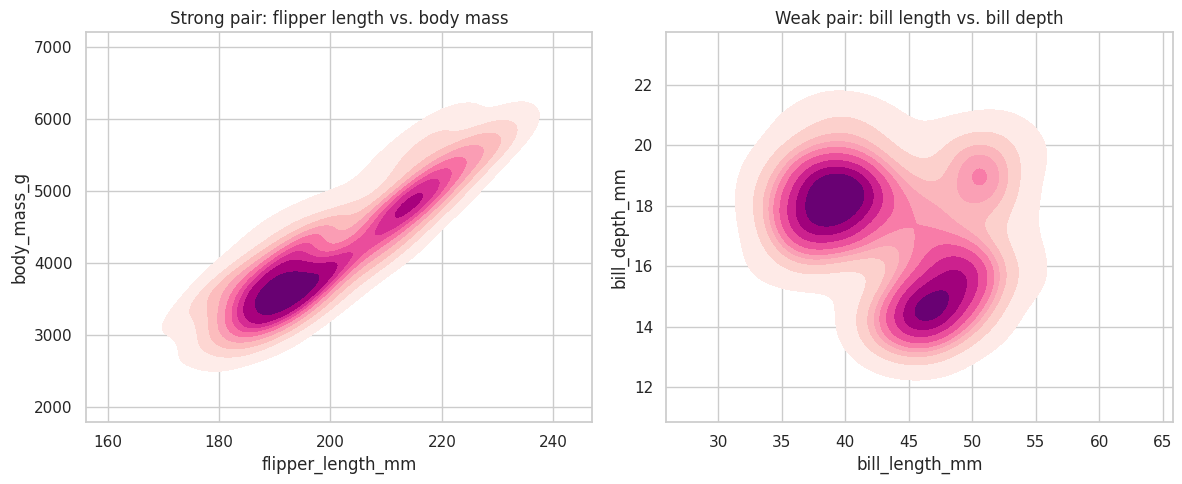

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(data=penguins, x="flipper_length_mm", y="body_mass_g",
            fill=True, cmap="RdPu", ax=axes[0])
axes[0].set_title("Strong pair: flipper length vs. body mass")

sns.kdeplot(data=penguins, x="bill_length_mm", y="bill_depth_mm",
            fill=True, cmap="RdPu", ax=axes[1])
axes[1].set_title("Weak pair: bill length vs. bill depth")

plt.tight_layout()
plt.show()


**Interpretation:** the difference is visible before we compute a single number. The left contour is a tight, clearly diagonal ellipse, tilted so it rises left-to-right — exactly the shape a strong positive relationship should produce. The right contour is rounder and more diffuse, with much less obvious tilt — consistent with a weak relationship. (We'll see in the Correlation vs. Causation section below that this particular pair's *overall* shape is hiding something more interesting once we split it by species — keep this contour shape in mind.)

Covariance and Pearson's $r$ are how we turn "the cloud looks tilted and tight" into an exact, comparable number instead of a judgment call from eyeballing a plot. That's the motivation for the rest of this notebook.


## Covariance

Recall: $\text{Cov}(X,Y) = \frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})$ — it measures the **direction** two features move together.

We'll use `flipper_length_mm` and `body_mass_g` as our main example throughout this notebook: bigger flippers, bigger body — an intuitive, physically sensible pair to start with.


In [ ]:
flipper = penguins["flipper_length_mm"]
body_mass = penguins["body_mass_g"]
n = len(penguins)

# --- By hand ---
flipper_mean = flipper.mean()
body_mass_mean = body_mass.mean()
cov_by_hand = sum((flipper - flipper_mean) * (body_mass - body_mass_mean)) / n

# --- With numpy ---
cov_numpy = np.cov(flipper, body_mass, ddof=0)[0, 1]

print(f"Covariance (by hand): {cov_by_hand:.2f}")
print(f"Covariance (numpy):   {cov_numpy:.2f}")


Covariance (by hand): 9795.69
Covariance (numpy):   9795.69


**Interpretation:** the hand-computed and numpy values match, and the sign is positive — flipper length and body mass move in the same direction. But notice the number itself (in the thousands) isn't very interpretable on its own: it's in units of "mm $\times$ g," which doesn't mean much intuitively, and we can't compare it to a covariance computed on a different pair of features with different units. That's exactly the limitation Pearson's $r$ fixes.


## Pearson's $r$

$r = \dfrac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2}\sqrt{\sum(y_i-\bar{y})^2}}$ — covariance, standardized by both features' spreads, into a unitless number between $-1$ and $1$.


In [ ]:
r, p_value = stats.pearsonr(flipper, body_mass)
print(f"Pearson's r: {r:.3f}")
print(f"p-value:     {p_value:.2e}")


Pearson's r: 0.871
p-value:     4.37e-107


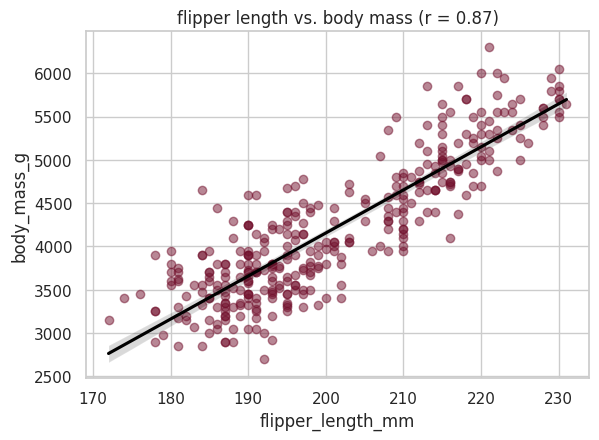

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.regplot(data=penguins, x="flipper_length_mm", y="body_mass_g",
            scatter_kws={"alpha": 0.5, "color": "#72112D"}, line_kws={"color": "black"}, ax=ax)
ax.set_title(f"flipper length vs. body mass (r = {r:.2f})")
plt.show()


**Interpretation:** $r \approx 0.87$ is a strong positive correlation, and unlike the covariance above, this number is directly interpretable and comparable to any other Pearson's $r$ you compute, regardless of units. The scatter confirms it visually — a tight, clearly linear cloud, exactly what a high $|r|$ should look like.


## Spearman vs. Pearson

A quick honesty check before we go further: every pair of numeric features in this penguin dataset turns out to be fairly **linear** (you can verify this — Pearson's $r$ and Spearman's $r_s$ come out close together for all of them). That's a genuine property of this dataset, not something to force otherwise.

To actually *see* Spearman earning its keep, we need a monotonic-but-curved relationship — so for this section only, we'll construct a small synthetic example, clearly labeled as such, the same way Notebook 01-03 fit a Gaussian to real data to check the fit honestly rather than assume it.


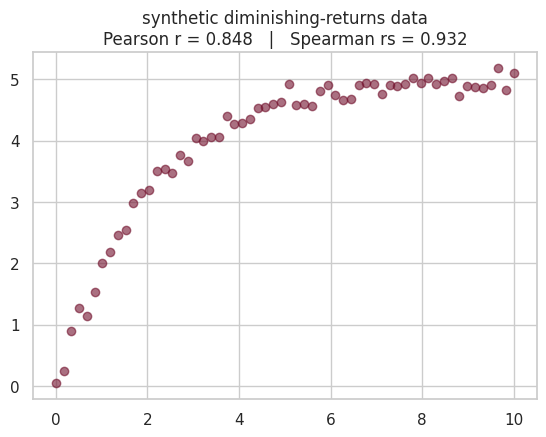

In [ ]:
# Synthetic example: a diminishing-returns relationship (monotonic, not linear)
rng = np.random.default_rng(42)
x_synth = np.linspace(0, 10, 60)
y_synth = 5 * (1 - np.exp(-0.5 * x_synth)) + rng.normal(0, 0.15, size=len(x_synth))

pearson_r, _ = stats.pearsonr(x_synth, y_synth)
spearman_r, _ = stats.spearmanr(x_synth, y_synth)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(x_synth, y_synth, alpha=0.6, color="#72112D")
ax.set_title(f"synthetic diminishing-returns data\nPearson r = {pearson_r:.3f}   |   Spearman rs = {spearman_r:.3f}")
plt.show()


**Interpretation:** Spearman's $r_s$ comes out noticeably higher than Pearson's $r$ here, because the relationship is perfectly monotonic (y always increases as x increases) but visibly curved, not straight. Pearson's $r$ only credits *linear* association, so it understates a real, strong, monotonic relationship. This is the exact situation from Lesson 1.4's training-hours-vs-skill-score example — when you see a curve like this in your own data, reach for Spearman.


## Correlation Heatmap

Let's look at all four numeric features from Palmer Penguins at once.


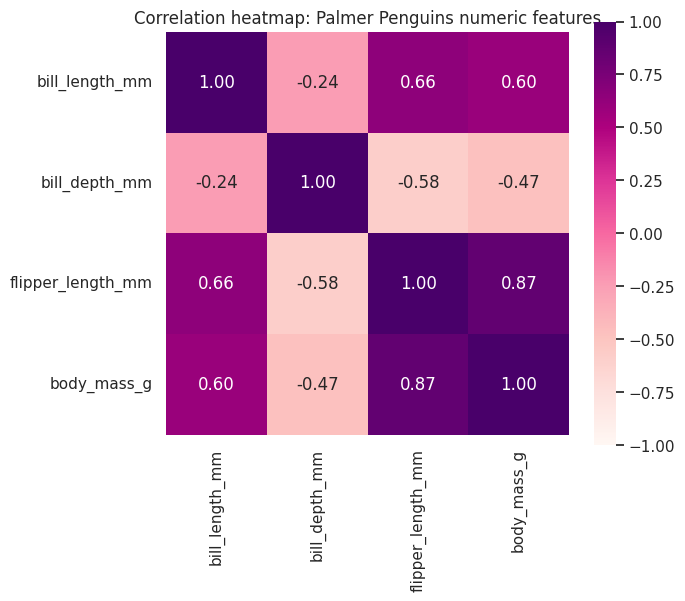

In [ ]:
corr_matrix = penguins[numeric_features].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdPu", vmin=-1, vmax=1,
            square=True, ax=ax)
ax.set_title("Correlation heatmap: Palmer Penguins numeric features")
plt.show()


**Interpretation:** `flipper_length_mm` and `body_mass_g` are the strongest pair (matching what we found above), and `bill_depth_mm` is negatively correlated with everything else — including, oddly, `bill_length_mm`, at $r \approx -0.24$. That last one is worth pausing on. Bill length and bill depth are two measurements of the *same beak* — why would a longer bill mean a shallower one? Let's look closer.


## Correlation vs. Causation

Lesson 1.4 warned that a correlation can hide a confounding variable. Let's find out if that's happening here — not illustrated, but actually investigated, the way you'd do it in real analysis.


In [ ]:
r_overall, p_overall = stats.pearsonr(penguins["bill_length_mm"], penguins["bill_depth_mm"])
print(f"Overall bill_length vs. bill_depth: r = {r_overall:.3f}")


Overall bill_length vs. bill_depth: r = -0.235


A weak **negative** correlation overall. Taken at face value, that would suggest longer-billed penguins tend to have shallower bills. Before accepting that, let's check whether it holds up *within* each species — exactly the check Lesson 1.4's confound diagram asked us to run.


In [ ]:
print("Within each species:")
for species in penguins["species"].unique():
    subset = penguins[penguins["species"] == species]
    r_species, _ = stats.pearsonr(subset["bill_length_mm"], subset["bill_depth_mm"])
    print(f"  {species:10s}: r = {r_species:.3f}  (n={len(subset)})")


Within each species:
  Adelie    : r = 0.391  (n=151)
  Gentoo    : r = 0.643  (n=123)
  Chinstrap : r = 0.654  (n=68)


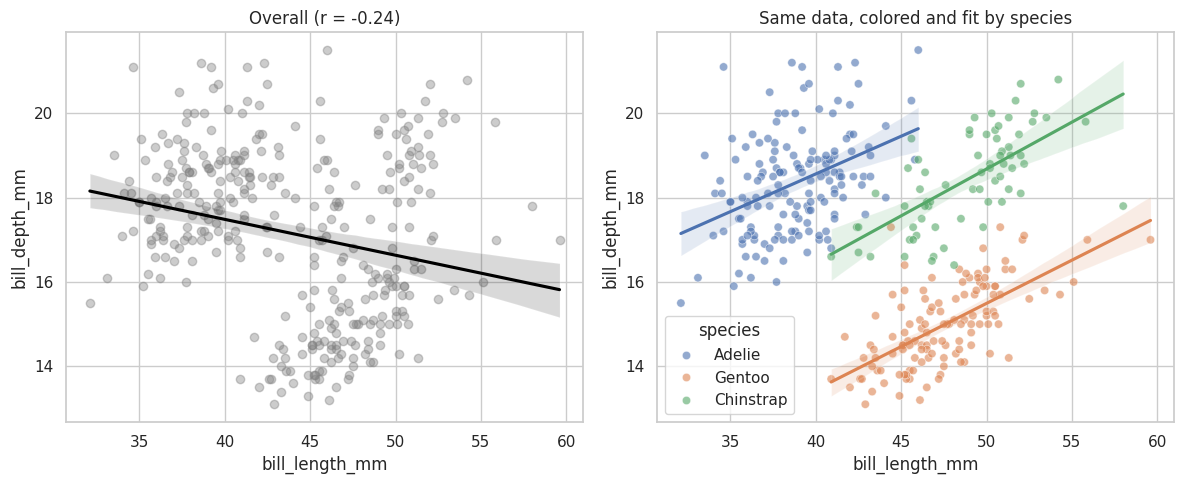

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: overall, no species information -- the misleading view
sns.regplot(data=penguins, x="bill_length_mm", y="bill_depth_mm",
            scatter_kws={"alpha": 0.4, "color": "gray"}, line_kws={"color": "black"}, ax=axes[0])
axes[0].set_title(f"Overall (r = {r_overall:.2f})")

# Right: colored and fit by species -- the confound revealed
sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", alpha=0.6, ax=axes[1])
for species in penguins["species"].unique():
    subset = penguins[penguins["species"] == species]
    sns.regplot(data=subset, x="bill_length_mm", y="bill_depth_mm",
                scatter=False, ax=axes[1], label=None)
axes[1].set_title("Same data, colored and fit by species")

plt.tight_layout()
plt.show()


**Interpretation:** this is a textbook case of **Simpson's Paradox** — a phenomenon where a trend or relationship that holds within every subgroup of a dataset reverses (or disappears) when the subgroups are combined into one. It's named after statistician Edward H. Simpson, who formally described it in Simpson, E.H. (1951), "The Interpretation of Interaction in Contingency Tables," *Journal of the Royal Statistical Society, Series B*, 13(2), 238–241. Related effects were noted earlier by Pearson et al. (1899) and Yule (1903), which is why it's sometimes called the **Yule–Simpson effect**.

In our case specifically: the correlation doesn't just weaken within species, it *flips sign entirely*. Overall, longer bills look associated with shallower bills ($r \approx -0.24$). But within every single species, longer bills are associated with **deeper** bills ($r \approx 0.39$ to $0.65$, all positive).

What's actually happening: species is a **confound**. Gentoo penguins have long, shallow bills as a species-level trait; Adelie penguins have short, deep bills as a species-level trait. Mix all three species into one scatter plot without accounting for species, and the *between-species* pattern (long-shallow vs. short-deep) swamps the *within-species* pattern (longer bill, deeper bill, for a given species) — and even reverses its apparent direction.

If someone reported "$r = -0.24$, longer bills predict shallower bills" without checking this, they'd have the relationship backwards for every individual penguin. This is exactly why Lesson 1.4 insisted: before trusting a correlation, ask *could a third variable explain this?* — and here, checking took three lines of code.

This also explains the "weak pair" contour plot from earlier in this notebook: its round, diffuse shape wasn't really one weak relationship — it was **three separate tight, tilted ellipses** (one per species, each a genuine positive relationship) sitting at different positions and partially overlapping, which blurs into something rounder and less clearly directional when you view it as a single blob. The contour plot was already showing us the confound; we just needed the species split to see it.

## Choosing the Right Method

Mirroring Notebook 01-03's "Choosing the Right Plot" table — here's the equivalent for correlation:

| Question | Best tool | Why |
|---|---|---|
| Do two features move in the same or opposite direction? | **Covariance** | Sign tells you direction, but the magnitude isn't comparable across feature pairs |
| How strong is a *linear* relationship, in a comparable, unitless way? | **Pearson's $r$** | Standardized to $[-1, 1]$; the standard first check |
| Is the relationship monotonic but curved? | **Spearman's $r_s$** | Based on ranks, so it captures monotonic (not just linear) association |
| How do many feature pairs compare at once? | **Correlation heatmap** | One view of every pairwise Pearson's $r$; good for spotting what to investigate further |
| Is a correlation actually meaningful, or could a confound explain it? | **Group by a candidate confound and recheck** | As we just did — sometimes the answer changes entirely, or even reverses |

The last row is the one worth remembering longest: **a correlation coefficient is a starting point for investigation, not an ending point for a conclusion.**


## Recap

In this notebook, we covered:

- **From 2D histograms to a number** — picking up Notebook 01-03's preview, connecting joint-distribution shape (round vs. elongated, tilt direction) to what correlation measures numerically
- **Covariance** — direction of a relationship, computed by hand and with `numpy`
- **Pearson's $r$** — covariance standardized into a comparable, unitless measure
- **Spearman's rank correlation** — for monotonic-but-curved relationships, demonstrated on a synthetic example after confirming the real dataset didn't have one
- **Correlation heatmaps** — all pairwise relationships in one view
- **Correlation vs. causation, genuinely investigated** — `bill_length_mm` and `bill_depth_mm` showed a real **Simpson's Paradox**: negatively correlated overall, positively correlated within every species

**Next up:** work through **Lab Activity 01-04: Correlation Analysis**, which applies everything from this notebook to a new dataset (car fuel economy) — including your own confound investigation, this time without the answer worked out for you in advance.
